In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.csv
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.csv


# The Hidden Gems/Niche Spot Index: Optimising Domestic Tourism Spillovers in Thailand
### Advanced Spatial & Economic Analysis for Secondary Market Usage
**Author:** Vaanya Kapur  
**Context:** Regional Economic Development Structure

In [2]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
import time

# Styling configurations for professional pandas displays
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Environment successfully initialized.")

Environment successfully initialized.


In [3]:
# ============================================================
# Hidden Gems Index: Thailand Secondary Tourism Opportunity
# ============================================================

# Core data tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping
import folium
from folium.plugins import HeatMap

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.csv
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.csv


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show every file available in your Kaggle input folder
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.csv
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.parquet
/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023.csv


In [6]:
file_path = "/kaggle/input/datasets/thaweewatboy/thailand-domestic-tourism-statistics/thailand_domestic_tourism_2019_2023_ver2.csv"

df_raw = pd.read_csv(file_path)

df_raw.head()

,date,province_thai,province_eng,region_thai,region_eng,variable,value
0,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,ratio_tourist_stay,93.37
1,2019-01-01,ลพบุรี,Lopburi,ภาคกลาง,central,ratio_tourist_stay,61.32
2,2019-01-01,พระนครศรีอยุธยา,Phra Nakhon Si Ayutthaya,ภาคกลาง,central,ratio_tourist_stay,73.37
3,2019-01-01,สระบุรี,Saraburi,ภาคกลาง,central,ratio_tourist_stay,67.33
4,2019-01-01,ชัยนาท,Chainat,ภาคกลาง,central,ratio_tourist_stay,79.31


In [7]:
df_raw.shape

(30800, 7)

In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30800 entries, 0 to 30799
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           30800 non-null  object 
 1   province_thai  30800 non-null  object 
 2   province_eng   30800 non-null  object 
 3   region_thai    30800 non-null  object 
 4   region_eng     30800 non-null  object 
 5   variable       30800 non-null  object 
 6   value          30800 non-null  float64
dtypes: float64(1), object(6)
memory usage: 1.6+ MB


In [9]:
df_raw.columns

Index(['date', 'province_thai', 'province_eng', 'region_thai', 'region_eng',
       'variable', 'value'],
      dtype='object')

In [10]:
df_raw["variable"].unique()

array(['ratio_tourist_stay', 'no_tourist_stay', 'no_tourist_all',
       'no_tourist_thai', 'no_tourist_foreign', 'revenue_all',
       'revenue_thai', 'revenue_foreign'], dtype=object)

In [11]:
df = df_raw.pivot_table(
    index=["date", "province_thai", "province_eng", "region_thai", "region_eng"],
    columns="variable",
    values="value",
    aggfunc="sum"
).reset_index()

df.head()

variable,date,province_thai,province_eng,region_thai,region_eng,no_tourist_all,no_tourist_foreign,no_tourist_stay,no_tourist_thai,ratio_tourist_stay,revenue_all,revenue_foreign,revenue_thai
0,2019-01-01,กระบี่,Krabi,ภาคใต้,south,"564,380.00","378,823.00","348,964.00","185,557.00",81.62,"10,844,790,000.00","7,855,390,000.00","2,989,400,000.00"
1,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,"5,959,075.00","2,425,014.00","3,334,971.00","3,534,061.00",93.37,"81,926,490,000.00","52,183,910,000.00","29,742,580,000.00"
2,2019-01-01,กาญจนบุรี,Kanchanaburi,ภาคกลาง,central,"752,901.00","45,211.00","339,491.00","707,690.00",83.80,"2,695,150,000.00","256,960,000.00","2,438,190,000.00"
3,2019-01-01,กาฬสินธุ์,Kalasin,ภาคตะวันออกเฉียงเหนือ,east_northeast,"62,141.00",522.00,"23,197.00","61,619.00",55.76,"93,880,000.00","1,160,000.00","92,720,000.00"
4,2019-01-01,กำแพงเพชร,Kamphaeng Phet,ภาคเหนือ,north,"74,421.00","2,238.00","45,815.00","72,183.00",57.35,"156,400,000.00","7,260,000.00","149,140,000.00"


In [12]:
df.columns.name = None

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,date,province_thai,province_eng,region_thai,region_eng,no_tourist_all,no_tourist_foreign,no_tourist_stay,no_tourist_thai,ratio_tourist_stay,revenue_all,revenue_foreign,revenue_thai
0,2019-01-01,กระบี่,Krabi,ภาคใต้,south,"564,380.00","378,823.00","348,964.00","185,557.00",81.62,"10,844,790,000.00","7,855,390,000.00","2,989,400,000.00"
1,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,"5,959,075.00","2,425,014.00","3,334,971.00","3,534,061.00",93.37,"81,926,490,000.00","52,183,910,000.00","29,742,580,000.00"
2,2019-01-01,กาญจนบุรี,Kanchanaburi,ภาคกลาง,central,"752,901.00","45,211.00","339,491.00","707,690.00",83.80,"2,695,150,000.00","256,960,000.00","2,438,190,000.00"
3,2019-01-01,กาฬสินธุ์,Kalasin,ภาคตะวันออกเฉียงเหนือ,east_northeast,"62,141.00",522.00,"23,197.00","61,619.00",55.76,"93,880,000.00","1,160,000.00","92,720,000.00"
4,2019-01-01,กำแพงเพชร,Kamphaeng Phet,ภาคเหนือ,north,"74,421.00","2,238.00","45,815.00","72,183.00",57.35,"156,400,000.00","7,260,000.00","149,140,000.00"


In [13]:
df.columns

Index(['date', 'province_thai', 'province_eng', 'region_thai', 'region_eng',
       'no_tourist_all', 'no_tourist_foreign', 'no_tourist_stay',
       'no_tourist_thai', 'ratio_tourist_stay', 'revenue_all',
       'revenue_foreign', 'revenue_thai'],
      dtype='object')

In [14]:
df = df.rename(columns={
    "province_eng": "province",
    "region_eng": "region",
    "no_tourist_all": "total_tourists",
    "no_tourist_thai": "thai_tourists",
    "no_tourist_foreign": "foreign_tourists",
    "revenue_all": "revenue",
    "ratio_tourist_stay": "occupancy_rate"
})

df.head()

,date,province_thai,province,region_thai,region,total_tourists,foreign_tourists,no_tourist_stay,thai_tourists,occupancy_rate,revenue,revenue_foreign,revenue_thai
0,2019-01-01,กระบี่,Krabi,ภาคใต้,south,"564,380.00","378,823.00","348,964.00","185,557.00",81.62,"10,844,790,000.00","7,855,390,000.00","2,989,400,000.00"
1,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,"5,959,075.00","2,425,014.00","3,334,971.00","3,534,061.00",93.37,"81,926,490,000.00","52,183,910,000.00","29,742,580,000.00"
2,2019-01-01,กาญจนบุรี,Kanchanaburi,ภาคกลาง,central,"752,901.00","45,211.00","339,491.00","707,690.00",83.80,"2,695,150,000.00","256,960,000.00","2,438,190,000.00"
3,2019-01-01,กาฬสินธุ์,Kalasin,ภาคตะวันออกเฉียงเหนือ,east_northeast,"62,141.00",522.00,"23,197.00","61,619.00",55.76,"93,880,000.00","1,160,000.00","92,720,000.00"
4,2019-01-01,กำแพงเพชร,Kamphaeng Phet,ภาคเหนือ,north,"74,421.00","2,238.00","45,815.00","72,183.00",57.35,"156,400,000.00","7,260,000.00","149,140,000.00"


In [15]:
df.columns

Index(['date', 'province_thai', 'province', 'region_thai', 'region',
       'total_tourists', 'foreign_tourists', 'no_tourist_stay',
       'thai_tourists', 'occupancy_rate', 'revenue', 'revenue_foreign',
       'revenue_thai'],
      dtype='object')

In [16]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df[["date", "year", "month"]].head()

,date,year,month
0,2019-01-01,2019,1
1,2019-01-01,2019,1
2,2019-01-01,2019,1
3,2019-01-01,2019,1
4,2019-01-01,2019,1


In [17]:
df.isna().sum()

date                0
province_thai       0
province            0
region_thai         0
region              0
total_tourists      0
foreign_tourists    0
no_tourist_stay     0
thai_tourists       0
occupancy_rate      0
revenue             0
revenue_foreign     0
revenue_thai        0
year                0
month               0
dtype: int64

In [18]:
# Fill missing numeric values with 0
numeric_cols = [
    "total_tourists",
    "foreign_tourists",
    "thai_tourists",
    "no_tourist_stay",
    "occupancy_rate",
    "revenue",
    "revenue_foreign",
    "revenue_thai"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(0)

# Drop rows only if province or region is missing
df = df.dropna(subset=["province", "region"])

df.isna().sum()

date                0
province_thai       0
province            0
region_thai         0
region              0
total_tourists      0
foreign_tourists    0
no_tourist_stay     0
thai_tourists       0
occupancy_rate      0
revenue             0
revenue_foreign     0
revenue_thai        0
year                0
month               0
dtype: int64

In [19]:
df[[
    "date",
    "year",
    "month",
    "province",
    "region",
    "total_tourists",
    "thai_tourists",
    "foreign_tourists",
    "occupancy_rate",
    "revenue"
]].head()

,date,year,month,province,region,total_tourists,thai_tourists,foreign_tourists,occupancy_rate,revenue
0,2019-01-01,2019,1,Krabi,south,"564,380.00","185,557.00","378,823.00",81.62,"10,844,790,000.00"
1,2019-01-01,2019,1,Bangkok,central,"5,959,075.00","3,534,061.00","2,425,014.00",93.37,"81,926,490,000.00"
2,2019-01-01,2019,1,Kanchanaburi,central,"752,901.00","707,690.00","45,211.00",83.80,"2,695,150,000.00"
3,2019-01-01,2019,1,Kalasin,east_northeast,"62,141.00","61,619.00",522.00,55.76,"93,880,000.00"
4,2019-01-01,2019,1,Kamphaeng Phet,north,"74,421.00","72,183.00","2,238.00",57.35,"156,400,000.00"


# The Hidden Gems Index: Optimizing Domestic Tourism Spillovers in Thailand

Thailand’s tourism economy is highly concentrated in a few major hotspots such as Bangkok, Phuket, Chiang Mai, etc. While these provinces generate large tourism revenues, said concentration can limit the spread of economic benefits to smaller provinces.

This project builds a **Thailand Niche Spot Index** to identify secondary Thai provinces with strong potential for future tourism growth. Instead of simply ranking provinces by total tourist numbers, the index combines multiple indicators of tourism opportunity:

1. Revenue per tourist
2. Domestic visitor resilience
3. Post-pandemic recovery strength
4. Accommodation occupancy rate
5. Lower crowd saturation

The goal is to identify provinces that are not already tourism mega-hubs, but may have strong potential for future domestic tourism spillovers.

In [20]:
province_summary = (
    df.groupby("province")
    .agg(
        region=("region", "first"),
        total_revenue=("revenue", "sum"),
        total_tourists=("total_tourists", "sum"),
        thai_tourists=("thai_tourists", "sum"),
        foreign_tourists=("foreign_tourists", "sum"),
        avg_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
)

province_summary.head()

,province,region,total_revenue,total_tourists,thai_tourists,foreign_tourists,avg_occupancy
0,Amnat Charoen,east_northeast,"1,075,100,000.00","841,477.00","828,599.00","12,878.00",32.45
1,Ang Thong,central,"2,556,650,000.00","2,293,450.00","2,251,377.00","42,073.00",32.43
2,Bangkok,central,"1,846,967,430,000.00","151,352,500.00","106,899,866.00","44,452,634.00",43.83
3,Bueng Kan,east_northeast,"2,990,700,000.00","1,976,525.00","1,949,037.00","27,488.00",39.64
4,Buriram,east_northeast,"15,069,820,000.00","7,570,251.00","7,455,232.00","115,019.00",44.38


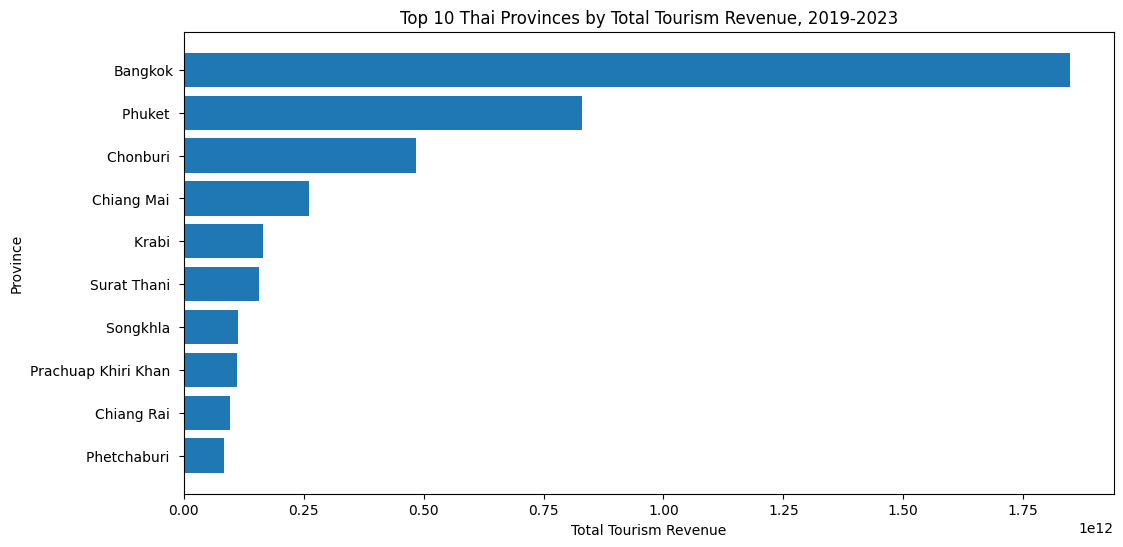

In [21]:
top_revenue = province_summary.sort_values("total_revenue", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_revenue["province"], top_revenue["total_revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Thai Provinces by Total Tourism Revenue, 2019-2023")
plt.xlabel("Total Tourism Revenue")
plt.ylabel("Province")
plt.show()

## Tourism Concentration

The chart above shows that Thailand's tourism revenue is concentrated in a small number of major provinces. Since this project focuses on identifying secondary-market opportunities, the next step removes the largest tourism hubs from the analysis.

In [22]:
# Part 6: Remove mega-tourism provinces

# Clean province names just in case there are hidden spaces
df["province"] = df["province"].astype(str).str.strip()

mega_tourism_provinces = [
    "Bangkok",
    "Phuket",
    "Chiang Mai",
    "Chonburi",
    "Chon Buri",
    "Surat Thani"
]

# Check which mega provinces exist in the dataset
print("Mega provinces found in dataset:")
print(df[df["province"].isin(mega_tourism_provinces)]["province"].unique())

# Remove mega tourism provinces
secondary_df = df[~df["province"].isin(mega_tourism_provinces)].copy()

print("Original number of provinces:", df["province"].nunique())
print("Number of secondary provinces:", secondary_df["province"].nunique())

# Final check
print("Mega provinces still in secondary_df:")
print(secondary_df[secondary_df["province"].isin(mega_tourism_provinces)]["province"].unique())

Mega provinces found in dataset:
['Bangkok' 'Chonburi' 'Phuket' 'Surat Thani' 'Chiang Mai']
Original number of provinces: 77
Number of secondary provinces: 72
Mega provinces still in secondary_df:
[]


In [23]:
# Parts 7-13: Rebuild secondary summary, create features, and calculate Hidden Gems Score

from sklearn.preprocessing import MinMaxScaler

# Rebuild secondary_summary using the filtered secondary_df
secondary_summary = (
    secondary_df.groupby("province")
    .agg(
        region=("region", "first"),
        total_revenue=("revenue", "sum"),
        total_tourists=("total_tourists", "sum"),
        thai_tourists=("thai_tourists", "sum"),
        foreign_tourists=("foreign_tourists", "sum"),
        avg_occupancy=("occupancy_rate", "mean")
    )
    .reset_index()
)

# Check that mega provinces are not inside secondary_summary
print("Mega provinces still in secondary_summary:")
print(secondary_summary[secondary_summary["province"].isin(mega_tourism_provinces)]["province"].unique())

# 1. Revenue per tourist
secondary_summary["revenue_per_tourist"] = (
    secondary_summary["total_revenue"] /
    secondary_summary["total_tourists"].replace(0, np.nan)
)

# 2. Domestic resilience ratio
secondary_summary["domestic_resilience_ratio"] = (
    secondary_summary["thai_tourists"] /
    (secondary_summary["thai_tourists"] + secondary_summary["foreign_tourists"]).replace(0, np.nan)
)

# 3. Recovery ratio
pre_pandemic = (
    secondary_df[secondary_df["year"] == 2019]
    .groupby("province")
    .agg(pre_revenue=("revenue", "sum"))
    .reset_index()
)

recovery_period = (
    secondary_df[secondary_df["year"].isin([2022, 2023])]
    .groupby("province")
    .agg(recovery_revenue=("revenue", "sum"))
    .reset_index()
)

secondary_summary = secondary_summary.merge(pre_pandemic, on="province", how="left")
secondary_summary = secondary_summary.merge(recovery_period, on="province", how="left")

secondary_summary["recovery_ratio"] = (
    secondary_summary["recovery_revenue"] /
    secondary_summary["pre_revenue"].replace(0, np.nan)
)

# 4. Low crowd advantage
secondary_summary["low_crowd_advantage"] = (
    1 / secondary_summary["total_tourists"].replace(0, np.nan)
)

# 5. Normalize indicators
features_to_scale = [
    "revenue_per_tourist",
    "domestic_resilience_ratio",
    "recovery_ratio",
    "avg_occupancy",
    "low_crowd_advantage"
]

secondary_summary = secondary_summary.replace([np.inf, -np.inf], np.nan)

for col in features_to_scale:
    secondary_summary[col] = secondary_summary[col].fillna(secondary_summary[col].median())

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(secondary_summary[features_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_scaled" for col in features_to_scale]
)

secondary_summary = pd.concat(
    [secondary_summary.reset_index(drop=True), scaled_df],
    axis=1
)

# 6. Calculate Hidden Gems Score
secondary_summary["hidden_gems_score"] = (
    0.30 * secondary_summary["revenue_per_tourist_scaled"] +
    0.20 * secondary_summary["domestic_resilience_ratio_scaled"] +
    0.20 * secondary_summary["recovery_ratio_scaled"] +
    0.20 * secondary_summary["avg_occupancy_scaled"] +
    0.10 * secondary_summary["low_crowd_advantage_scaled"]
)

secondary_summary["hidden_gems_score"] = secondary_summary["hidden_gems_score"] * 100

secondary_summary = secondary_summary.sort_values(
    "hidden_gems_score",
    ascending=False
)

secondary_summary.head(15)

Mega provinces still in secondary_summary:
[]


,province,region,total_revenue,total_tourists,thai_tourists,foreign_tourists,avg_occupancy,revenue_per_tourist,domestic_resilience_ratio,pre_revenue,recovery_revenue,recovery_ratio,low_crowd_advantage,revenue_per_tourist_scaled,domestic_resilience_ratio_scaled,recovery_ratio_scaled,avg_occupancy_scaled,low_crowd_advantage_scaled,hidden_gems_score
8,Chiang Rai,north,"95,557,770,000.00","13,554,804.00","12,364,453.00","1,190,351.00",47.39,"7,049.73",0.91,"29,291,710,000.00","43,368,340,000.00",1.48,0.00,0.43,0.85,0.80,0.80,0.03,62.27
28,Nan,north,"9,189,250,000.00","3,787,855.00","3,737,552.00","50,303.00",52.22,"2,425.98",0.99,"2,723,910,000.00","3,893,950,000.00",1.43,0.00,0.11,0.98,0.77,1.00,0.19,60.10
43,Phrae,north,"6,340,620,000.00","3,219,437.00","3,121,243.00","98,194.00",44.36,"1,969.48",0.97,"1,760,690,000.00","2,920,220,000.00",1.66,0.00,0.07,0.95,0.91,0.67,0.22,55.10
37,Phayao,north,"5,038,420,000.00","2,558,312.00","2,476,731.00","81,581.00",42.11,"1,969.43",0.97,"1,403,160,000.00","2,256,270,000.00",1.61,0.00,0.07,0.95,0.88,0.58,0.29,53.19
3,Buriram,east_northeast,"15,069,820,000.00","7,570,251.00","7,455,232.00","115,019.00",44.38,"1,990.66",0.98,"4,703,950,000.00","7,081,260,000.00",1.51,0.00,0.08,0.98,0.82,0.67,0.08,52.45
54,Samut Songkhram,central,"11,316,710,000.00","9,892,126.00","9,780,814.00","111,312.00",41.10,"1,144.01",0.99,"3,081,410,000.00","5,575,560,000.00",1.81,0.00,0.02,0.98,1.00,0.54,0.06,51.48
15,Lampang,north,"13,421,950,000.00","4,671,728.00","4,489,830.00","181,898.00",45.74,"2,873.02",0.96,"4,351,570,000.00","5,184,750,000.00",1.19,0.00,0.14,0.94,0.63,0.73,0.15,51.45
39,Phetchaburi,central,"83,774,300,000.00","28,039,834.00","27,306,554.00","733,280.00",49.87,"2,987.69",0.97,"31,034,390,000.00","29,347,480,000.00",0.95,0.00,0.15,0.96,0.48,0.90,0.00,51.22
24,Nakhon Phanom,east_northeast,"6,649,310,000.00","4,136,989.00","3,961,597.00","175,392.00",45.45,"1,607.28",0.96,"2,182,030,000.00","2,743,700,000.00",1.26,0.00,0.05,0.93,0.67,0.72,0.17,49.43
12,Kanchanaburi,central,"77,869,050,000.00","33,877,750.00","33,180,427.00","697,323.00",48.96,"2,298.53",0.98,"27,883,920,000.00","26,284,600,000.00",0.94,0.00,0.10,0.97,0.48,0.86,0.00,49.13


In [24]:
# Part 14: Final ranking table

top_hidden_gems = secondary_summary[
    [
        "province",
        "region",
        "hidden_gems_score",
        "revenue_per_tourist",
        "domestic_resilience_ratio",
        "recovery_ratio",
        "avg_occupancy",
        "total_tourists",
        "total_revenue"
    ]
].head(15)

top_hidden_gems

,province,region,hidden_gems_score,revenue_per_tourist,domestic_resilience_ratio,recovery_ratio,avg_occupancy,total_tourists,total_revenue
8,Chiang Rai,north,62.27,"7,049.73",0.91,1.48,47.39,"13,554,804.00","95,557,770,000.00"
28,Nan,north,60.10,"2,425.98",0.99,1.43,52.22,"3,787,855.00","9,189,250,000.00"
43,Phrae,north,55.10,"1,969.48",0.97,1.66,44.36,"3,219,437.00","6,340,620,000.00"
37,Phayao,north,53.19,"1,969.43",0.97,1.61,42.11,"2,558,312.00","5,038,420,000.00"
3,Buriram,east_northeast,52.45,"1,990.66",0.98,1.51,44.38,"7,570,251.00","15,069,820,000.00"
54,Samut Songkhram,central,51.48,"1,144.01",0.99,1.81,41.10,"9,892,126.00","11,316,710,000.00"
15,Lampang,north,51.45,"2,873.02",0.96,1.19,45.74,"4,671,728.00","13,421,950,000.00"
39,Phetchaburi,central,51.22,"2,987.69",0.97,0.95,49.87,"28,039,834.00","83,774,300,000.00"
24,Nakhon Phanom,east_northeast,49.43,"1,607.28",0.96,1.26,45.45,"4,136,989.00","6,649,310,000.00"
12,Kanchanaburi,central,49.13,"2,298.53",0.98,0.94,48.96,"33,877,750.00","77,869,050,000.00"


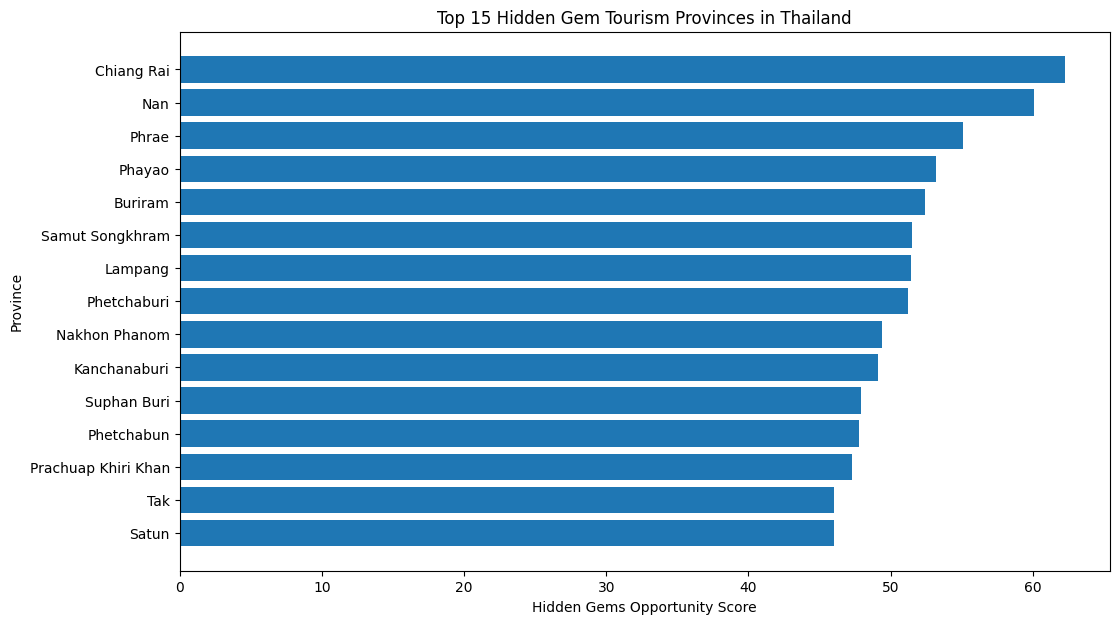

In [25]:
# Part 15: Visualize top hidden gems

plt.figure(figsize=(12, 7))
plt.barh(top_hidden_gems["province"], top_hidden_gems["hidden_gems_score"])
plt.gca().invert_yaxis()
plt.title("Top 15 Hidden Gem Tourism Provinces in Thailand")
plt.xlabel("Hidden Gems Opportunity Score")
plt.ylabel("Province")
plt.show()

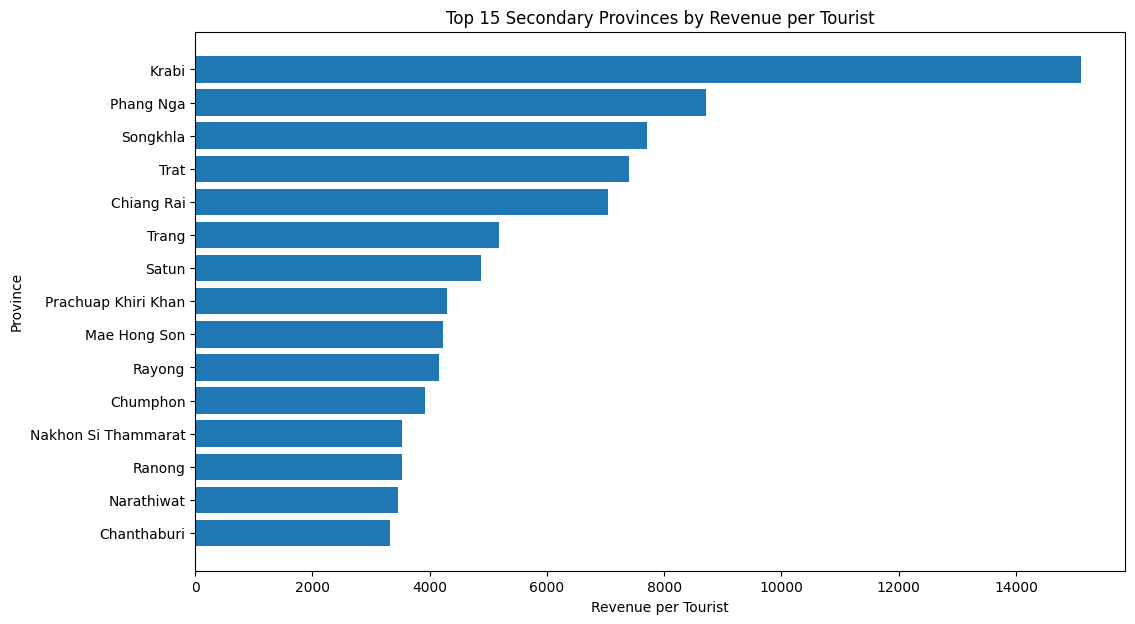

In [26]:
# Part 16: Visualize revenue per tourist

top_value = secondary_summary.sort_values(
    "revenue_per_tourist",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))
plt.barh(top_value["province"], top_value["revenue_per_tourist"])
plt.gca().invert_yaxis()
plt.title("Top 15 Secondary Provinces by Revenue per Tourist")
plt.xlabel("Revenue per Tourist")
plt.ylabel("Province")
plt.show()

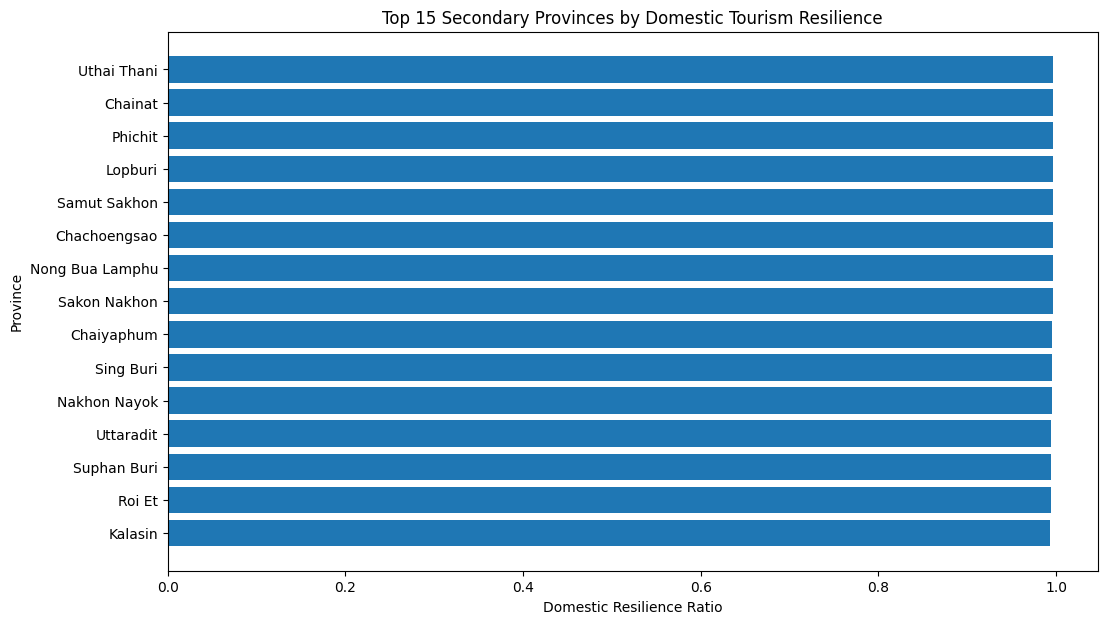

In [27]:
# Part 17: Visualize domestic resilience

top_resilience = secondary_summary.sort_values(
    "domestic_resilience_ratio",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))
plt.barh(top_resilience["province"], top_resilience["domestic_resilience_ratio"])
plt.gca().invert_yaxis()
plt.title("Top 15 Secondary Provinces by Domestic Tourism Resilience")
plt.xlabel("Domestic Resilience Ratio")
plt.ylabel("Province")
plt.show()

## Methodology

This project constructs a composite indicator called the **Hidden Gems/Niche Spot Index**. The purpose of the index is to identify secondary Thai provinces that may be well-positioned for future domestic tourism growth.

The analysis first removes five major tourism hubs: Bangkok, Phuket, Chiang Mai, Chonburi, and Surat Thani. This allows the project to focus on secondary tourism markets rather than provinces that already dominate Thailand’s tourism economy.

Each remaining province is evaluated using five indicators:

1. **Revenue per tourist**  
   This measures how much tourism revenue is generated per visitor. A higher value suggests that tourists spend more in that province.

2. **Domestic resilience ratio**  
   This measures the share of tourists who are Thai domestic visitors. A higher ratio suggests lower dependence on international tourism.

3. **Recovery ratio**  
   This compares tourism revenue during the recovery period, 2022-2023, with pre-pandemic revenue in 2019.

4. **Average occupancy rate**  
   This measures how actively accommodation capacity is being used.

5. **Low crowd advantage**  
   This rewards provinces with lower total tourist numbers, helping identify less saturated destinations.

Each indicator is normalized using min-max scaling. The final score is calculated using a weighted average.

## Hidden Gems Index Formula

The final score is calculated using the following weighted formula:

\[
Hidden\ Gems\ Score =
0.30(Revenue\ per\ Tourist) +
0.20(Domestic\ Resilience) +
0.20(Recovery\ Ratio) +
0.20(Occupancy\ Rate) +
0.10(Low\ Crowd\ Advantage)
\]

The score is then multiplied by 100 for readability.

In [28]:
province_coordinates = {
    "Amnat Charoen": [15.8585, 104.6288],
    "Ang Thong": [14.5896, 100.4550],
    "Bueng Kan": [18.3609, 103.6464],
    "Buriram": [14.9930, 103.1029],
    "Buri Ram": [14.9930, 103.1029],
    "Chachoengsao": [13.6904, 101.0779],
    "Chai Nat": [15.1852, 100.1251],
    "Chainat": [15.1852, 100.1251],
    "Chaiyaphum": [15.8068, 102.0315],
    "Chanthaburi": [12.6113, 102.1038],
    "Chiang Rai": [19.9105, 99.8406],
    "Chumphon": [10.4930, 99.1800],
    "Kalasin": [16.4385, 103.5061],
    "Kamphaeng Phet": [16.4828, 99.5227],
    "Kanchanaburi": [14.0228, 99.5328],
    "Khon Kaen": [16.4322, 102.8236],
    "Krabi": [8.0863, 98.9063],
    "Lampang": [18.2888, 99.4909],
    "Lamphun": [18.5745, 99.0087],
    "Loei": [17.4860, 101.7223],
    "Lopburi": [14.7995, 100.6534],
    "Lop Buri": [14.7995, 100.6534],
    "Mae Hong Son": [19.3020, 97.9654],
    "Maha Sarakham": [16.1851, 103.3026],
    "Mukdahan": [16.5421, 104.7235],
    "Nakhon Nayok": [14.2069, 101.2131],
    "Nakhon Pathom": [13.8199, 100.0622],
    "Nakhon Phanom": [17.3920, 104.7696],
    "Nakhon Ratchasima": [14.9799, 102.0977],
    "Nakhon Sawan": [15.7047, 100.1372],
    "Phra Nakhon Si Ayutthaya": [14.3692, 100.5877],
    "Nakhon Si Ayutthaya": [14.3692, 100.5877],
    "Nakhon Si Thammarat": [8.4325, 99.9599],
    "Nan": [18.7756, 100.7730],
    "Narathiwat": [6.4254, 101.8253],
    "Nong Bua Lamphu": [17.2218, 102.4260],
    "Nong Bua Lam Phu": [17.2218, 102.4260],
    "Nong Khai": [17.8783, 102.7413],
    "Nonthaburi": [13.8621, 100.5144],
    "Pathum Thani": [14.0208, 100.5250],
    "Pattani": [6.8695, 101.2501],
    "Phang Nga": [8.4501, 98.5255],
    "Phatthalung": [7.6167, 100.0740],
    "Phayao": [19.1665, 99.9019],
    "Phetchabun": [16.4189, 101.1551],
    "Phetchaburi": [13.1119, 99.9447],
    "Phichit": [16.4429, 100.3488],
    "Phitsanulok": [16.8211, 100.2659],
    "Phrae": [18.1446, 100.1402],
    "Prachinburi": [14.0509, 101.3727],
    "Prachin Buri": [14.0509, 101.3727],
    "Prachuap Khiri Khan": [11.8124, 99.7973],
    "Ranong": [9.9529, 98.6085],
    "Ratchaburi": [13.5283, 99.8134],
    "Rayong": [12.6814, 101.2816],
    "Roi Et": [16.0538, 103.6520],
    "Sa Kaeo": [13.8240, 102.0646],
    "Sakon Nakhon": [17.1546, 104.1348],
    "Samut Prakan": [13.5991, 100.5998],
    "Samut Sakhon": [13.5475, 100.2744],
    "Samut Songkhram": [13.4098, 100.0023],
    "Saraburi": [14.5289, 100.9101],
    "Satun": [6.6238, 100.0674],
    "Sing Buri": [14.8936, 100.3967],
    "Sisaket": [15.1186, 104.3220],
    "Songkhla": [7.1898, 100.5951],
    "Sukhothai": [17.0056, 99.8264],
    "Suphan Buri": [14.4745, 100.1177],
    "Surin": [14.8829, 103.4937],
    "Tak": [16.8838, 99.1258],
    "Trang": [7.5594, 99.6114],
    "Trat": [12.2428, 102.5175],
    "Ubon Ratchathani": [15.2448, 104.8473],
    "Udon Thani": [17.4138, 102.7872],
    "Uthai Thani": [15.3835, 100.0246],
    "Uttaradit": [17.6201, 100.0993],
    "Yala": [6.5411, 101.2804],
    "Yasothon": [15.7926, 104.1453]
}

coord_df = pd.DataFrame.from_dict(
    province_coordinates,
    orient="index",
    columns=["latitude", "longitude"]
).reset_index()

coord_df = coord_df.rename(columns={"index": "province"})

coord_df.head()

,province,latitude,longitude
0,Amnat Charoen,15.86,104.63
1,Ang Thong,14.59,100.45
2,Bueng Kan,18.36,103.65
3,Buriram,14.99,103.10
4,Buri Ram,14.99,103.10


In [29]:
map_df = secondary_summary.merge(coord_df, on="province", how="left")

missing_coordinates = map_df[map_df["latitude"].isna()][["province"]]

missing_coordinates

,province


In [30]:
import folium

map_df_clean = map_df.dropna(subset=["latitude", "longitude"]).copy()

thailand_map = folium.Map(
    location=[13.7563, 100.5018],
    zoom_start=6,
    tiles="CartoDB positron"
)

for _, row in map_df_clean.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5 + row["hidden_gems_score"] / 10,
        popup=(
            f"<b>{row['province']}</b><br>"
            f"Region: {row['region']}<br>"
            f"Hidden Gems Score: {row['hidden_gems_score']:.2f}<br>"
            f"Revenue per Tourist: {row['revenue_per_tourist']:.2f}<br>"
            f"Domestic Resilience Ratio: {row['domestic_resilience_ratio']:.2f}<br>"
            f"Recovery Ratio: {row['recovery_ratio']:.2f}<br>"
            f"Average Occupancy: {row['avg_occupancy']:.2f}"
        ),
        tooltip=row["province"],
        fill=True,
        fill_opacity=0.7
    ).add_to(thailand_map)

thailand_map

In [31]:
from folium.plugins import HeatMap

heat_data = map_df_clean[
    ["latitude", "longitude", "hidden_gems_score"]
].values.tolist()

heat_map = folium.Map(
    location=[13.7563, 100.5018],
    zoom_start=6,
    tiles="CartoDB positron"
)

HeatMap(
    heat_data,
    radius=20,
    blur=15,
    max_zoom=8
).add_to(heat_map)

heat_map

In [32]:
thailand_map.save("hidden_gems_interactive_map.html")
heat_map.save("hidden_gems_heatmap.html")

print("Maps saved successfully.")

Maps saved successfully.


## Limitations

This project has several limitations.

First, the Hidden Gems Index only uses tourism statistics from the dataset. It does not include transport access, airport availability, hotel quality, road conditions, environmental carrying capacity, or local government tourism budgets.

Second, the analysis uses province-level data. This means it may hide differences within provinces. A province can contain both highly developed tourist areas and less developed rural areas.

Third, the index weights are subjective. This project gives the highest weight to revenue per tourist, but a government agency focused on equality or sustainability might choose different weights.

Finally, the dataset ends in early 2023, so the results should be interpreted as a post-pandemic recovery snapshot rather than a fully current tourism forecast.

## Policy Recommendations

The Hidden Gems Index can help identify secondary provinces that may benefit from targeted tourism promotion and infrastructure support.

High-scoring provinces may be suitable for:

- Domestic tourism campaigns  
   Provinces with strong domestic resilience can be promoted to Thai travelers, especially during low seasons.

-  Local business support  
   Small hotels, restaurants, markets, and tour operators in high-potential provinces could benefit from grants or training.

-  Infrastructure investment  
   Provinces with strong visitor value but lower tourist volume may need better transport, accommodation, and digital tourism services.

-  Regional branding  
   Provinces can be promoted based on local food, nature, culture, festivals, or historical identity.

-  Sustainable tourism planning  
   The goal should not be to recreate overcrowding in secondary provinces. Tourism growth should be managed carefully to protect local communities and environments.

## Conclusion

This project developed a Hidden Gems/Niche Spot Index to identify secondary Thai provinces with strong potential for future domestic tourism spillovers. Instead of ranking provinces only by total tourism size, the index combines visitor value, domestic resilience, recovery strength, occupancy rate, and lower crowd saturation.

The results show how data science can support tourism policy by highlighting provinces that may be overlooked by traditional tourism rankings. These provinces may offer opportunities for more balanced regional growth if supported through infrastructure investment, and sustainable tourism planning.

In [33]:
print("Final dataset shape:", df.shape)
print("Number of total provinces:", df["province"].nunique())
print("Number of secondary provinces analyzed:", secondary_summary["province"].nunique())

print("\nTop 5 Hidden Gem Provinces:")
secondary_summary[
    ["province", "region", "hidden_gems_score"]
].head(5)

Final dataset shape: (3850, 15)
Number of total provinces: 77
Number of secondary provinces analyzed: 72

Top 5 Hidden Gem Provinces:


,province,region,hidden_gems_score
8,Chiang Rai,north,62.27
28,Nan,north,60.10
43,Phrae,north,55.10
37,Phayao,north,53.19
3,Buriram,east_northeast,52.45
